In [78]:
# 1. Split data into training and testing

# 2. Feature Selection

# SelectKBest (t-statistics, ANOVA, chi squared)

# Refine features

# LASSO

# XGBoost (Gradient Boosting)

# PCA

# UMAP

# 3. Model training

# Logistics Regression

# Train a Random Forest Classifier

# SVM

In [1]:
import sys

#!pip install XXX --target ./my_custom_packages
sys.path.append('./my_custom_packages')
#import dask.dataframe as dd
#import matplotlib.pyplot as plt
import polars as pl
import time
#import GEOparse
#pl.Config.set_tbl_rows(20)



from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression

#from sklearn.feature_selection import mutual_info_classif
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectFdr, chi2, SelectKBest, SelectFpr, SelectFromModel
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import xgboost as xgb
import optuna
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

import umap


#from tempfile import mkdtemp
#from shutil import rmtree

from sklearn.svm import SVC


2026-06-12 21:04:45.292954: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-12 21:04:45.308439: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781316285.326192 2449670 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781316285.331388 2449670 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-12 21:04:45.350551: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# Reading and transposing the cost matrix
cost_matrix = pl.read_parquet("cost_matrix_processed.parquet").transpose(include_header=True, header_name="Sample")
# Reading the annotation data
annot_data = pl.read_parquet("annot_data_processed.parquet")
# Reading the merged dataset
#merged_dataset = pl.read_parquet("merged_dataset_processed.parquet")

In [3]:
'''
# Casting sample to integer
cost_matrix = cost_matrix.with_columns(
    pl.col("Sample").cast(pl.Int32)
# Sorting by sample
).sort("Sample")

# Casting sample to integer
annot_data = annot_data.with_columns(
    pl.col("Sample").cast(pl.Int32)
# Sorting by sample
).sort("Sample")
'''

# Casting sample to integer
cost_matrix = cost_matrix.with_columns(
    pl.col("Sample").cast(pl.Int32)
)


# Joining data on sample
mdf = cost_matrix.join(annot_data, on = "Sample")

# Filtering out ex-smokers
mdf = mdf.filter(pl.col("Status") != "Ex-smoker")

# Getting the status column
y = mdf.get_column("Status")


# Displaying the cost matrix head
display(cost_matrix.head())
# Displaying the annotation data head
display(annot_data.head())



# Creating a binary gender column
mdf = mdf.with_columns(
    Gender = (pl.col("Gender") == "Male").cast(pl.Int8)
)


# Dropping sample and status columns
mdf = mdf.drop(["Sample", "Status"])


# Displaying the modified dataframe head
display(mdf.head())

Sample,column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,…,column_203379,column_203380,column_203381,column_203382,column_203383,column_203384,column_203385,column_203386,column_203387,column_203388,column_203389,column_203390,column_203391,column_203392,column_203393,column_203394,column_203395,column_203396,column_203397,column_203398,column_203399,column_203400,column_203401,column_203402,column_203403,column_203404,column_203405,column_203406,column_203407,column_203408,column_203409,column_203410,column_203411,column_203412,column_203413,column_203414,column_203415
i32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
1900017,2,2,2,2,1,1,0,0,1,2,1,1,1,0,2,1,1,1,2,1,0,2,2,1,1,1,0,1,0,1,0,0,2,2,2,0,…,2,0,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2
1900029,0,2,1,1,2,1,0,1,2,2,2,2,1,1,2,2,1,2,0,1,0,1,2,0,2,2,1,0,1,2,1,0,2,2,2,0,…,2,0,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2
1900030,2,2,1,2,2,2,0,1,2,2,1,1,2,2,2,2,1,2,0,2,0,1,2,1,1,1,2,0,2,1,1,1,2,2,2,0,…,2,0,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2
1900031,1,2,2,2,2,1,0,0,2,1,0,2,1,1,1,1,2,2,1,2,0,0,2,1,2,0,1,1,1,1,1,0,2,1,2,2,…,2,0,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2
1900040,2,2,2,1,2,1,0,0,2,2,1,1,1,1,2,1,2,2,1,2,0,2,1,1,1,2,1,1,0,1,1,0,2,1,1,0,…,2,0,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2


Sample,Status,Age,Gender
i32,str,i8,str
200026,"""Smoker""",39,"""Male"""
200027,"""Smoker""",42,"""Male"""
200028,"""Smoker""",32,"""Female"""
200032,"""Smoker""",33,"""Male"""
200033,"""Smoker""",48,"""Female"""


column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,…,column_203381,column_203382,column_203383,column_203384,column_203385,column_203386,column_203387,column_203388,column_203389,column_203390,column_203391,column_203392,column_203393,column_203394,column_203395,column_203396,column_203397,column_203398,column_203399,column_203400,column_203401,column_203402,column_203403,column_203404,column_203405,column_203406,column_203407,column_203408,column_203409,column_203410,column_203411,column_203412,column_203413,column_203414,column_203415,Age,Gender
i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
1,2,1,2,2,2,0,0,1,2,1,1,1,1,1,1,0,0,0,1,2,1,1,1,2,2,2,1,2,1,1,0,1,2,1,0,0,…,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2,39,1
1,2,1,0,1,2,0,0,2,2,0,1,2,1,2,2,2,2,0,1,0,1,2,2,2,1,2,2,1,2,1,2,2,2,2,0,0,…,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2,42,1
1,2,2,2,2,1,0,0,1,2,2,2,1,1,1,2,1,2,1,1,0,1,1,2,2,1,2,0,1,2,0,1,2,2,0,0,0,…,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2,32,0
1,1,2,2,1,2,0,0,2,2,1,1,1,0,2,1,2,1,1,2,0,2,2,0,2,1,2,0,1,1,2,1,2,2,1,0,1,…,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2,33,1
2,2,1,1,2,2,0,0,2,2,1,2,1,1,2,1,2,2,0,1,0,1,1,0,2,2,2,1,1,1,1,0,2,2,2,0,0,…,0,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,2,2,2,2,0,2,0,2,2,2,2,2,2,2,2,2,2,2,2,48,0


In [4]:
# Splitting the data


# Splitting into train and test sets
x_train, x_test, y_train, y_test = train_test_split(mdf, y, test_size = 0.2, random_state = 4, stratify = y)

# Converting train labels to integers
y_train_int = (y_train == "Smoker").to_numpy().astype("int")
# Converting test labels to integers
y_test_int = (y_test == "Smoker").to_numpy().astype("int")

# Printing the number of columns in train
print(x_train.shape[1])


# Initializing a min max scaler
scaler = MinMaxScaler()
# Fitting and transforming the train age
age_train_scaled = scaler.fit_transform(x_train.select("Age")).flatten()
# Transforming the test age
age_test_scaled = scaler.transform(x_test.select("Age")).flatten()

# Replacing age with scaled age in train
x_train = x_train.with_columns(AgeScaled = pl.Series(age_train_scaled)).drop("Age")
# Replacing age with scaled age in test
x_test = x_test.with_columns(AgeScaled = pl.Series(age_test_scaled)).drop("Age")

# Calculating Minor Allele Frequency

# Converting train to numpy arrays
x_train_np = x_train.select(pl.exclude(["Age", "Gender"])).to_numpy()
# Converting test to numpy arrays
x_test_np = x_test.select(pl.exclude(["Age", "Gender"])).to_numpy()

# Getting the number of samples
N = x_train_np.shape[0]
# Calculating the allele frequency
AF = x_train_np.sum(axis = 0) /(2*N)

# Calculating the minor allele frequency
MAF = np.minimum(AF, 1 - AF)

# Creating a mask for frequent alleles
kept_identifiers = MAF > 0.01

# Appending true values to the mask
kept_identifiers = np.append(kept_identifiers, [True, True])

# Initializing a list for columns to keep
cols_to_keep = []
# Initializing an index counter
i = 0
# Looping through train columns
for col in x_train.columns:
    # Checking if the identifier is kept
    if kept_identifiers[i]:
        # Appending the column to the list
        cols_to_keep.append(col)
    # Incrementing the counter
    i += 1

# Selecting significant columns for train
x_train_significant1 = x_train.select(cols_to_keep).to_numpy()
# Selecting significant columns for test
x_test_significant1 = x_test.select(cols_to_keep).to_numpy()

# Printing the number of significant columns
print(x_train_significant1.shape[1])
# Displaying the head of the significant train data
display(pd.DataFrame(x_train_significant1).head())

203418
46323


,0,1,2,3,4,5,6,7,8,9,...,46313,46314,46315,46316,46317,46318,46319,46320,46321,46322
0,1.0,2.0,0.0,2.0,1.0,1.0,0.0,0.0,2.0,2.0,...,2.0,2.0,1.0,2.0,2.0,2.0,0.0,0.0,1.0,0.569444
1,0.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.597222
2,1.0,1.0,2.0,2.0,2.0,2.0,0.0,1.0,1.0,2.0,...,1.0,2.0,1.0,2.0,2.0,2.0,0.0,0.0,0.0,0.388889
3,1.0,2.0,1.0,2.0,2.0,2.0,0.0,1.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.375000
4,0.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,2.0,2.0,...,2.0,2.0,1.0,2.0,2.0,2.0,0.0,0.0,1.0,0.416667


In [5]:
# Selecting K best features

# Initializing the select k best object
select = SelectKBest(score_func = chi2, k = "all")

# Fitting and transforming the data
select.fit_transform(x_train_significant1, y_train)

# Sorting the chi scores
chi_scores = np.sort(np.nan_to_num(select.scores_))[::-1]

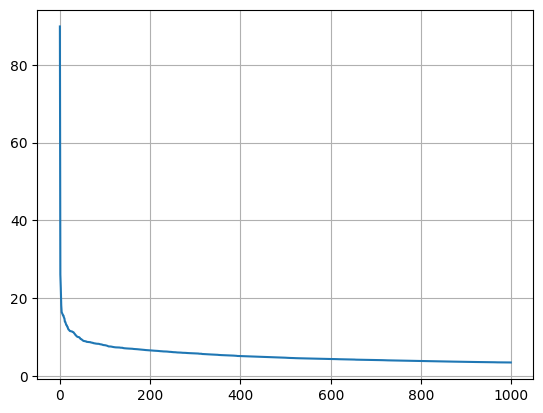

In [107]:
# Creating a new figure
plt.figure()

# Plotting the top 1000 chi scores
plt.plot(chi_scores[:1000])

# Adding a grid to the plot
plt.grid()

In [5]:
# Selecting features using FDR and FPR
'''
# Initializing the select fdr object
select = SelectFdr(score_func = chi2, alpha = 0.01)

# Fitting and transforming train data
x_train_significant2 = select.fit_transform(x_train_significant1, y_train)

# Transforming test data
x_test_significant2 = select.transform(x_test_significant1)

print(x_train_significant2.shape[1])

# Logging 3 significant features

'''

# Initializing the select fpr object
select = SelectFpr(score_func=chi2, alpha=0.01)

# Fitting and transforming train data
x_train_significant2 = select.fit_transform(x_train_significant1, y_train)
# Transforming test data
x_test_significant2 = select.transform(x_test_significant1)

print(x_train_significant2.shape[1])

# Calculating Events Per Variable

189


In [6]:
# Applying LASSO regression
#display(pl.DataFrame(x_train_significant).head())
#display(pl.DataFrame(x_train_significant).describe())




# Initializing stratified k fold
cv_strategy = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 4)

# Generating lambda values to try
lambdas_to_try = np.logspace(-4, 2, 100)

# Initializing logistic regression CV
logistic_lasso = LogisticRegressionCV(
    # Setting the cross validation strategy
    cv = cv_strategy,
    # Setting the C parameters
    Cs = 1/lambdas_to_try,
    # Setting the maximum iterations
    max_iter = 10000,
    # Setting the random state
    random_state = 4,
    # Setting the penalty type
    penalty = "l1", #absolute value
    # Setting the solver
    solver = "liblinear", #Coordinate descent, one variable at a time
    # Setting the scoring metric
    scoring = 'roc_auc', #TP rate and TN rate
    # Using all processors
    n_jobs = -1
)


# Fitting the lasso model
logistic_lasso.fit(x_train_significant2, y_train)


# Finding significant features
significant_features = logistic_lasso.coef_[0] != 0

# Filtering train data with significant features
x_train_significant3 = x_train_significant2[:, significant_features]
# Filtering test data with significant features
x_test_significant3 = x_test_significant2[:, significant_features]

# Getting the optimal C value
optimal_C = logistic_lasso.C_[0]
# Calculating the optimal lambda
optimal_lambda = 1 / optimal_C
# Printing the optimal lambda
print(optimal_lambda)

# Printing the number of significant features
print(x_train_significant3.shape[1])

0.0001
189


Score: 0.5909
fpr:  0.42, tpr: 0.58


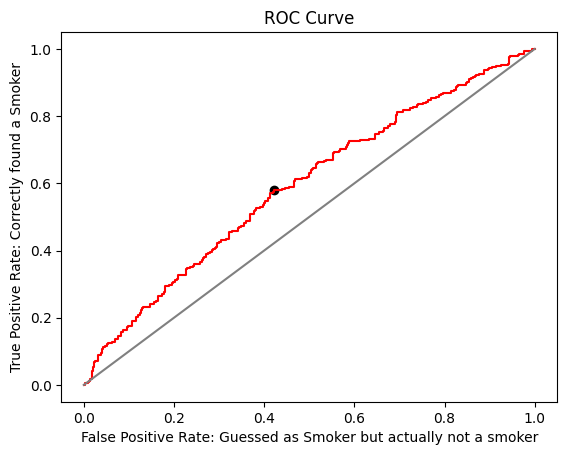

In [110]:
# Getting the index for the smoker class
smoker_index = list(logistic_lasso.classes_).index("Smoker")

# Predicting probabilities for the lasso model
y_proba_lasso = logistic_lasso.predict_proba(x_test_significant2)[:, smoker_index]

# Converting test labels to integers
y_test_int = (y_test == "Smoker").to_numpy().astype(int)

# Calculating the roc auc score
score_lasso = roc_auc_score(y_test_int, y_proba_lasso)

print(f"roc auc score: {score_lasso:.2f}")

# Calculating the roc curve metrics
fpr, tpr, thresholds = roc_curve(y_test_int, y_proba_lasso)

# Plotting the lasso model roc curve
plt.plot(fpr, tpr, color="red", label="LASSO model")


# Plotting the random guess line
plt.plot([0, 1], [0, 1], color="gray", label="Random guess")
# Setting the x axis label
plt.xlabel("False Positive Rate: Guessed as Smoker but actually not a smoker")
# Setting the y axis label
plt.ylabel("True Positive Rate: Correctly found a Smoker")
# Setting the plot title
plt.title("ROC Curve")

# Calculating Youden J-statistic

# Subtracting false positive rate from true positive rate
J = tpr - fpr
# Finding the index of the maximum J value
i = np.argmax(J)
# Getting the efficient threshold
efficient_threshold = thresholds[i]

# Plotting the best tradeoff point
plt.scatter(fpr[i], tpr[i], marker="o", color = "black", label=f"best tradeoff: {efficient_threshold:.2f}")

# Printing the false and true positive rates
print(f"fpr: {fpr[i]: .2f}, tpr: {tpr[i]:.2f}")


# Showing the plot
plt.show()

In [ ]:
# Using XGBOOST



'''
# Starting the timer
time1 = time.time()

# Initializing the XGB classifier
xgb_model = xgb.XGBClassifier(
    # Setting the objective
    objective = "binary:logistic",
    # Setting the random state
    random_state = 4,
    # Setting the evaluation metric
    eval_metric = "auc"
)



# Defining the parameter grid
param_grid = {
    # Setting max depth
    "max_depth": [1],
    # Setting learning rate
    "learning_rate": [0.35],
    # Setting number of estimators
    "n_estimators": [1200],
    # Setting subsample
    "subsample": [1],
    # Setting min child weight
    "min_child_weight": [5]
} 

# Initializing the grid search CV
xgb_grid = GridSearchCV(
    # Setting the estimator
    estimator = xgb_model,
    # Setting the parameter grid
    param_grid = param_grid,
    # Setting the cross validation strategy
    cv = cv_strategy,
    # Setting the scoring metric
    scoring = 'roc_auc',
    # Setting the number of jobs
    n_jobs = 8,
    # Setting the verbosity
    verbose  = 1
)


# Converting training labels to integers
#y_train_int = (y_train == "Smoker").to_numpy().astype("int")


# Fitting the grid search model
xgb_grid.fit(x_train_significant3, y_train_int)

#print(xgb_grid.best_params_)



# Predicting probabilities using the grid model
y_proba_xgb = xgb_grid.predict_proba(x_test_significant3)[:, 1]

# Calculating the roc auc score
score_lasso = roc_auc_score(y_test_int, y_proba_xgb)

print(f"Score: {score_lasso:.4f}")

# Printing the elapsed time
print(f"Took: {time.time() - time1:.2f}")

'''

# Logging Score: 0.5769

In [102]:
# Setting Total Server Cores = (Optuna n_jobs) * (XGBoost n_jobs)
# Setting simultaneous Optuna trials
OPTUNA_TRIALS_AT_ONCE = 14
# Setting XGBoost cores per trial
XGBOOST_CORES_PER_TRIAL = 8


# Defining the objective function for Optuna
def objective(trial):
    # Setting parameter suggestions
    param = {
        # Suggesting max depth
        "max_depth": trial.suggest_int('max_depth', 1, 20),
        # Suggesting learning rate
        "learning_rate": trial.suggest_float('learning_rate', 0.0001, 1.0),
        # Suggesting number of estimators
        "n_estimators": trial.suggest_int('n_estimators', 200, 2000),
        # Suggesting subsample
        "subsample": trial.suggest_float('subsample', 0.01, 1.0),
        # Suggesting min child weight
        "min_child_weight": trial.suggest_int('min_child_weight', 1, 15)    
    }
    
    # Initializing the XGB classifier
    model = xgb.XGBClassifier(
        # Unpacking parameters
        **param, 
        # Setting the objective
        objective = "binary:logistic",
        # Setting the random state
        random_state = 4,
        # Setting the evaluation metric
        eval_metric = "auc",
        # Setting the number of jobs
        n_jobs = XGBOOST_CORES_PER_TRIAL
    )

    # Creating a pipeline
    pipeline = Pipeline([
        # Adding the chi2 feature selection step
        ('chi2', SelectFpr(score_func=chi2, alpha=0.01)),
        # Adding the XGB model step
        ('xgb', model)
    ])
    
    # Calculating cross validation scores
    scores = cross_val_score(pipeline, x_train_significant1, y_train_int, cv = cv_strategy, scoring = "roc_auc")
    
    # Returning the mean score
    return scores.mean() 

# Creating the Optuna study
study = optuna.create_study(direction = "maximize")
# Optimizing the study
study.optimize(objective, n_trials = 300, n_jobs = OPTUNA_TRIALS_AT_ONCE)

print(f"Best AUC Score: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

[I 2026-06-02 22:20:45,245] A new study created in memory with name: no-name-a030ca6f-fcfe-4768-9057-4d4de4d7730c
[I 2026-06-02 22:21:13,372] Trial 7 finished with value: 0.5372159080664382 and parameters: {'max_depth': 7, 'learning_rate': 0.7164504464828606, 'n_estimators': 584, 'subsample': 0.16550467450051004, 'min_child_weight': 5}. Best is trial 7 with value: 0.5372159080664382.
[I 2026-06-02 22:21:13,768] Trial 9 finished with value: 0.5614035569220632 and parameters: {'max_depth': 18, 'learning_rate': 0.8248353817005689, 'n_estimators': 368, 'subsample': 0.6336880655999824, 'min_child_weight': 2}. Best is trial 9 with value: 0.5614035569220632.
[I 2026-06-02 22:21:14,204] Trial 13 finished with value: 0.5524026168675449 and parameters: {'max_depth': 1, 'learning_rate': 0.18618952959709054, 'n_estimators': 1090, 'subsample': 0.8074764815566398, 'min_child_weight': 14}. Best is trial 9 with value: 0.5614035569220632.
[I 2026-06-02 22:21:14,808] Trial 12 finished with value: 0.5716

[I 2026-06-02 22:22:12,043] Trial 28 finished with value: 0.5509665258224044 and parameters: {'max_depth': 12, 'learning_rate': 0.5655570782530535, 'n_estimators': 236, 'subsample': 0.6151899779208557, 'min_child_weight': 9}. Best is trial 23 with value: 0.5876916887542599.
[I 2026-06-02 22:22:14,569] Trial 31 finished with value: 0.5735674884562616 and parameters: {'max_depth': 11, 'learning_rate': 0.5323583653758615, 'n_estimators': 208, 'subsample': 0.9955066037525833, 'min_child_weight': 3}. Best is trial 23 with value: 0.5876916887542599.
[I 2026-06-02 22:22:15,250] Trial 30 finished with value: 0.5590754651917564 and parameters: {'max_depth': 13, 'learning_rate': 0.551881835904145, 'n_estimators': 275, 'subsample': 0.9909213790409601, 'min_child_weight': 7}. Best is trial 23 with value: 0.5876916887542599.
[I 2026-06-02 22:22:18,424] Trial 29 finished with value: 0.560144838674515 and parameters: {'max_depth': 12, 'learning_rate': 0.5715229138253756, 'n_estimators': 657, 'subsamp

[I 2026-06-02 22:23:16,049] Trial 58 finished with value: 0.5863988627962975 and parameters: {'max_depth': 7, 'learning_rate': 0.01815960170046164, 'n_estimators': 377, 'subsample': 0.8447984107385199, 'min_child_weight': 2}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:23:16,821] Trial 56 finished with value: 0.5893739560641302 and parameters: {'max_depth': 11, 'learning_rate': 0.029501697391795464, 'n_estimators': 456, 'subsample': 0.810828218452262, 'min_child_weight': 2}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:23:19,001] Trial 59 finished with value: 0.5899805073917627 and parameters: {'max_depth': 7, 'learning_rate': 0.013543209218122854, 'n_estimators': 380, 'subsample': 0.824259757420256, 'min_child_weight': 2}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:23:24,307] Trial 60 finished with value: 0.5909536758836268 and parameters: {'max_depth': 7, 'learning_rate': 0.03573066282829529, 'n_estimators': 364, 'subs

[I 2026-06-02 22:24:18,594] Trial 86 finished with value: 0.5845391847834105 and parameters: {'max_depth': 18, 'learning_rate': 0.16232989783262167, 'n_estimators': 307, 'subsample': 0.873188551332025, 'min_child_weight': 4}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:24:26,818] Trial 87 finished with value: 0.5775223928854182 and parameters: {'max_depth': 19, 'learning_rate': 0.1469700531924483, 'n_estimators': 586, 'subsample': 0.885356400153144, 'min_child_weight': 4}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:24:29,766] Trial 88 finished with value: 0.5757896027675466 and parameters: {'max_depth': 19, 'learning_rate': 0.1299734124955673, 'n_estimators': 603, 'subsample': 0.8705349807073589, 'min_child_weight': 4}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:24:30,931] Trial 89 finished with value: 0.5727963589483847 and parameters: {'max_depth': 19, 'learning_rate': 0.14035240234172422, 'n_estimators': 591, 'subsa

[I 2026-06-02 22:25:24,957] Trial 116 finished with value: 0.5848137511863374 and parameters: {'max_depth': 8, 'learning_rate': 0.03165456012074218, 'n_estimators': 424, 'subsample': 0.7309192406302186, 'min_child_weight': 3}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:25:25,453] Trial 115 finished with value: 0.5885968682333695 and parameters: {'max_depth': 10, 'learning_rate': 0.03181581648647205, 'n_estimators': 413, 'subsample': 0.7216816161233385, 'min_child_weight': 3}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:25:26,038] Trial 117 finished with value: 0.5860849833462007 and parameters: {'max_depth': 8, 'learning_rate': 0.02649989710486854, 'n_estimators': 417, 'subsample': 0.7675202710065552, 'min_child_weight': 3}. Best is trial 53 with value: 0.5949811271966705.
[I 2026-06-02 22:25:35,279] Trial 118 finished with value: 0.5872664616085669 and parameters: {'max_depth': 10, 'learning_rate': 0.03785802229602834, 'n_estimators': 505, 

...

[I 2026-06-02 22:28:58,314] Trial 205 finished with value: 0.5868471149259677 and parameters: {'max_depth': 11, 'learning_rate': 0.0011222048519155818, 'n_estimators': 291, 'subsample': 0.7834401778674593, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:28:58,340] Trial 204 finished with value: 0.5842330595537241 and parameters: {'max_depth': 11, 'learning_rate': 0.0015772061294272127, 'n_estimators': 279, 'subsample': 0.8284303807933706, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:28:58,400] Trial 207 finished with value: 0.5869291361169438 and parameters: {'max_depth': 11, 'learning_rate': 0.0011504179904947027, 'n_estimators': 264, 'subsample': 0.7878895597075554, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:28:58,905] Trial 206 finished with value: 0.5852922651625795 and parameters: {'max_depth': 11, 'learning_rate': 0.00017368961237840957, 'n_esti

[I 2026-06-02 22:30:02,954] Trial 231 finished with value: 0.5869972347480867 and parameters: {'max_depth': 10, 'learning_rate': 0.029466936823916705, 'n_estimators': 333, 'subsample': 0.8390713412191256, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:30:03,104] Trial 232 finished with value: 0.5908340975886414 and parameters: {'max_depth': 10, 'learning_rate': 0.03216985777503438, 'n_estimators': 356, 'subsample': 0.8402362060421837, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:30:03,257] Trial 235 finished with value: 0.5918903004732237 and parameters: {'max_depth': 10, 'learning_rate': 0.024079400932298402, 'n_estimators': 332, 'subsample': 0.6949630105437832, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:30:03,275] Trial 234 finished with value: 0.5867809361533329 and parameters: {'max_depth': 10, 'learning_rate': 0.030421998283369847, 'n_estimators

[I 2026-06-02 22:31:20,746] Trial 263 finished with value: 0.5874493030319422 and parameters: {'max_depth': 18, 'learning_rate': 0.04465302173743217, 'n_estimators': 409, 'subsample': 0.8964695187171563, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:31:22,863] Trial 252 finished with value: 0.5872735017727444 and parameters: {'max_depth': 18, 'learning_rate': 0.06473582514964443, 'n_estimators': 1379, 'subsample': 0.8919656285989007, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:31:23,590] Trial 257 finished with value: 0.5837076155890052 and parameters: {'max_depth': 11, 'learning_rate': 0.05985346821539106, 'n_estimators': 1195, 'subsample': 0.8143686199833875, 'min_child_weight': 1}. Best is trial 159 with value: 0.5952863273291141.
[I 2026-06-02 22:31:26,495] Trial 264 finished with value: 0.5903291891435587 and parameters: {'max_depth': 18, 'learning_rate': 0.04188224628053713, 'n_estimators'

[I 2026-06-02 22:32:41,173] Trial 292 finished with value: 0.592960808045293 and parameters: {'max_depth': 19, 'learning_rate': 0.017252827296596142, 'n_estimators': 372, 'subsample': 0.9443024858659617, 'min_child_weight': 2}. Best is trial 275 with value: 0.6002601500481092.
[I 2026-06-02 22:32:41,906] Trial 289 finished with value: 0.5908786928078863 and parameters: {'max_depth': 19, 'learning_rate': 0.019057710307967424, 'n_estimators': 489, 'subsample': 0.7769590058002397, 'min_child_weight': 2}. Best is trial 275 with value: 0.6002601500481092.
[I 2026-06-02 22:32:42,226] Trial 290 finished with value: 0.5921499044783312 and parameters: {'max_depth': 19, 'learning_rate': 0.018289581964249527, 'n_estimators': 477, 'subsample': 0.9371333354762206, 'min_child_weight': 2}. Best is trial 275 with value: 0.6002601500481092.
[I 2026-06-02 22:32:42,227] Trial 291 finished with value: 0.5889414100981689 and parameters: {'max_depth': 19, 'learning_rate': 0.022697801724437538, 'n_estimators

Best AUC Score: 0.6003
Best Parameters:
    max_depth: 19
    learning_rate: 0.017452477362781698
    n_estimators: 379
    subsample: 0.799389036857462
    min_child_weight: 1


In [115]:
# Starting the timer
time1 = time.time()

# Defining the best parameters found by Optuna
best_optuna_params = {
    # Setting max depth
    "max_depth": 19,
    # Setting learning rate
    "learning_rate": 0.01745,
    # Setting number of estimators
    "n_estimators": 379,
    # Setting subsample
    "subsample": 0.7994,
    # Setting min child weight
    "min_child_weight": 1
}

# Initializing the final XGB model
xgb_model_final = xgb.XGBClassifier(
    # Unpacking the best parameters
    **best_optuna_params,
    # Setting the objective
    objective = "binary:logistic",
    # Setting the random state
    random_state = 4,
    # Setting the evaluation metric
    eval_metric = "auc",
    # Using all available cores
    n_jobs = -1
)

# Fitting the final model
xgb_model_final.fit(x_train_significant3, y_train_int)
# Predicting probabilities with the final model
y_proba_xgb = xgb_model_final.predict_proba(x_test_significant3)[:, 1]

# Calculating the final AUC score
score_xgb = roc_auc_score(y_test_int, y_proba_xgb)
print(f"Final AUC Score: {score_xgb:.4f}")
# Printing the elapsed time
print(f"Took: {time.time() - time1:.2f} seconds")

Final AUC Score: 0.6018
Took: 346.90 seconds
Final AUC Score: 0.6018
Took: 346.90 seconds


In [5]:
# Applying PCA



# Initializing standard scaler
scaler = StandardScaler()
# Fitting and transforming the filtered data
data_scaled = scaler.fit_transform(mdf.filter(pl.int_range(0, pl.len()) != 128))


# Initializing PCA
pca = PCA(random_state = 4)

# Fitting and transforming scaled data
principal_components = pca.fit_transform(data_scaled)

In [10]:
# Getting the explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Printing sorted explained variance
#print(np.sort(explained_variance)[::-1])
# Printing max explained variance
#print(max(explained_variance))
# Printing length of explained variance
#print(len(explained_variance))

'''
# Creating a new figure
fig = plt.figure()
# Adding a subplot
ax = fig.add_subplot()

# Plotting a scatter of principal components
ax.scatter(principal_components[:, 0], principal_components[:, 1])

# Showing the plot
plt.show()

# Finding the minimum argument
np.argmin(principal_components[:, 0])'''

# Displaying conditions where the second component is greater than -50
display(np.where(principal_components[:, 1] > -50))
# Displaying an indexed condition array
display(np.where(principal_components[:, 14 > -50][0]))

(array([   0,    1,    2, ..., 3391, 3392, 3393]),)

(array([0, 0, 0, ..., 0, 0, 0]),
 array([   0,    1,    2, ..., 3391, 3392, 3393]))

In [11]:
# Filtering scaled data
clean_data_scaled = data_scaled[np.where(principal_components[:, 1] > -50)[0], :]

# Fitting PCA on clean data
clean_principal_components = pca.fit_transform(clean_data_scaled)

In [ ]:
'''fig2 = plt.figure()
ax2 = fig2.add_subplot()

# Plotting pca that explain most variance.
ax2.scatter(clean_principal_components[:, 0], clean_principal_components[:, 1])

plt.show()'''

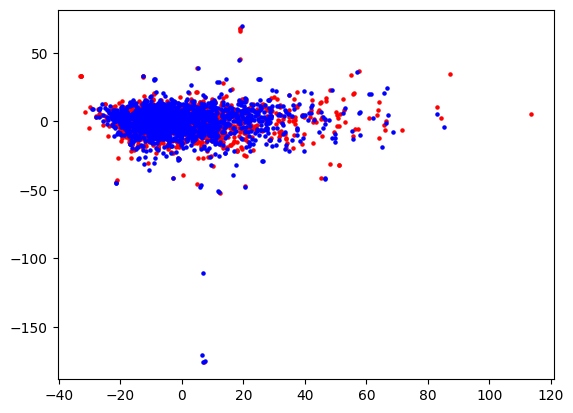

In [12]:
# Filtering more error clean scaled data
er_clean_data_scaled = clean_data_scaled[np.where(clean_principal_components[:, 0] > -100)[0], : ]
# Fitting PCA on error clean data
er_clean_principal_components = pca.fit_transform(er_clean_data_scaled)


# Converting y to numpy array
y_np = np.array(y)

# Filtering y labels
clean_y = y_np[np.where(principal_components[:, 1] > -50)[0]]
# Filtering error clean y labels
er_clean_y = clean_y[np.where(clean_principal_components[:, 0] > -100)[0]]

# Creating a boolean mask for smokers
smoker = (er_clean_y == "Smoker")



# Creating a new figure
fig3 = plt.figure()
# Adding a subplot
ax3 = fig3.add_subplot()

# Plotting pca that explain most variance.
# Plotting a scatter of smokers
ax3.scatter(er_clean_principal_components[smoker, 0], er_clean_principal_components[smoker, 1], color = "red", s = 5)
# Plotting a scatter of non-smokers
ax3.scatter(er_clean_principal_components[~smoker, 0], er_clean_principal_components[~smoker, 1], color = "blue", s = 5)

# Showing the plot
plt.show()

In [ ]:
# Applying UMAP

# Initializing the UMAP reducer
reducer = umap.UMAP(n_components = 2)

# Fitting and transforming the dataframe
result = reducer.fit_transform(mdf)

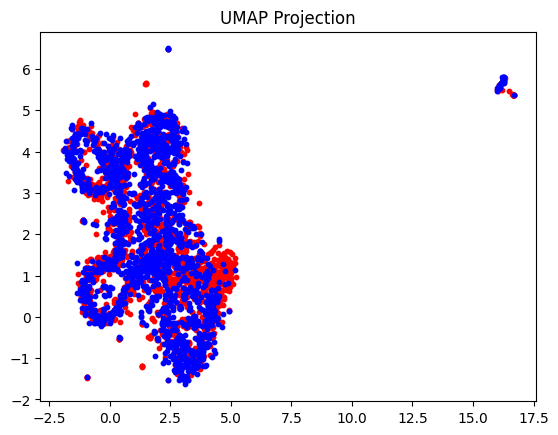

In [40]:
# Creating a boolean mask for smokers
s = y == "Smoker"

# Plotting a scatter for smokers
plt.scatter(
    # Setting x coordinates
    result[s, 0], 
    # Setting y coordinates
    result[s, 1], 
    # Setting point size
    s=10, 
    # Setting the label
    label="Smoker", 
    # Setting the color
    color="red"
)

# Plotting a scatter for non-smokers
plt.scatter(
    # Setting x coordinates
    result[~s, 0], 
    # Setting y coordinates
    result[~s, 1], 
    # Setting point size
    s=10, 
    # Setting the label
    label="Non-smoker", 
    # Setting the color
    color="blue"
)
# Setting the plot title
plt.title('UMAP Projection')
# Showing the plot
plt.show()

Accuracy score: 0.58
Confusion matrix: 
[[206 142]
 [146 185]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.59      0.59      0.59       348
           1       0.57      0.56      0.56       331

    accuracy                           0.58       679
   macro avg       0.58      0.58      0.58       679
weighted avg       0.58      0.58      0.58       679

ROC AUC Score: 0.59
fpr:  0.49, tpr: 0.64


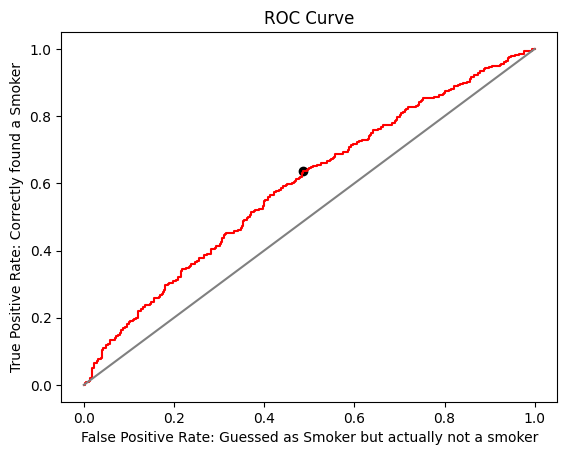

In [29]:
# Applying LogisticRegression


# Initializing logistic regression
lr = LogisticRegression()

# Fitting the model
lr.fit(x_train_significant3, y_train_int)

# Predicting classes
y_predict = lr.predict(x_test_significant3)
# Predicting probabilities
y_proba = lr.predict_proba(x_test_significant3)

print(f"Accuracy score: {accuracy_score(y_test_int, y_predict):.2f}")
print("Confusion matrix: ")
print(confusion_matrix(y_test_int, y_predict))
print("Classification Report: ")
print(classification_report(y_test_int, y_predict))


# Calculating the ROC AUC score
lr_auc_score = roc_auc_score(y_test_int, y_proba[:, 1])
print(f"ROC AUC Score: {lr_auc_score:.2f}")


# Calculating ROC curve metrics
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test_int, y_proba[:, 1])



# Plotting the LR model ROC curve
plt.plot(lr_fpr, lr_tpr, color="red", label="LR model")


# Plotting the random guess line
plt.plot([0, 1], [0, 1], color="gray", label="Random guess")
# Setting the x axis label
plt.xlabel("False Positive Rate: Guessed as Smoker but actually not a smoker")
# Setting the y axis label
plt.ylabel("True Positive Rate: Correctly found a Smoker")
# Setting the plot title
plt.title("ROC Curve")

# Calculating Youden's J-statistic

# Subtracting false positive rate from true positive rate
J2 = lr_tpr - lr_fpr
# Finding the maximum J index
i = np.argmax(J2)
# Getting the efficient threshold
lr_efficient_threshold = lr_thresholds[i]

# Plotting the best tradeoff point
plt.scatter(lr_fpr[i], lr_tpr[i], marker="o", color = "black", label=f"best tradeoff: {lr_efficient_threshold:.2f}")

# Printing the false and true positive rates
print(f"fpr: {lr_fpr[i]: .2f}, tpr: {lr_tpr[i]:.2f}")


# Showing the plot
plt.show()

In [62]:
'''test = SelectKBest(score_func = chi2, k = 6000)

test_x_train = test.fit_transform(x_train, y_train)
test_x_test = test.transform(x_test)


# LogisticRegression


lrT = LogisticRegression(max_iter=10000)

lrT.fit(test_x_train, y_train_int)

Ty_predict = lrT.predict(test_x_test)
Ty_proba = lrT.predict_proba(test_x_test)

print(f"Accuracy score: {accuracy_score(y_test_int, Ty_predict):.2f}")

Tlr_auc_score = roc_auc_score(y_test_int, Ty_proba[:, 1])
print(f"ROC AUC Score: {Tlr_auc_score:.2f}")

'''

Accuracy score: 0.54
ROC AUC Score: 0.55


In [55]:
'''
# Initializing PCA
pca = PCA(n_components=10, random_state=4)

# Fitting and transforming train PCA
train_pcs = pca.fit_transform(x_train_significant1)
# Transforming test PCA
test_pcs = pca.transform(x_test_significant1)

# Initializing select K best
test = SelectKBest(score_func=chi2, k=6000)
# Fitting and transforming train SNPs
train_snps_6k = test.fit_transform(x_train_significant1, y_train)
# Transforming test SNPs
test_snps_6k = test.transform(x_test_significant1)

# Horizontally stacking train features
final_x_train = np.hstack((train_snps_6k, train_pcs))
# Horizontally stacking test features
final_x_test = np.hstack((test_snps_6k, test_pcs))

# Defining l1 ratios to test
l1_ratios_to_test = [0.1, 0.5, 0.9]

# Initializing logistic regression CV
lr_cv_pca = LogisticRegressionCV(
    # Setting C parameters
    Cs=10,                  
    # Setting cross validation folds
    cv=5,                   
    # Setting penalty type
    penalty='elasticnet',
    # Setting solver
    solver='saga',          
    # Setting l1 ratios
    l1_ratios=l1_ratios_to_test,    
    # Setting scoring metric
    scoring='roc_auc',      
    # Setting maximum iterations
    max_iter=5000,
    # Setting random state
    random_state=4,
    # Using all cores
    n_jobs=-1               
)

# Fitting the model
lr_cv_pca.fit(final_x_train, y_train_int)

print(f"Best C value found: {lr_cv_pca.C_[0]:.4f}")
print(f"Best l1_ratio found: {lr_cv_pca.l1_ratio_[0]}")

# Predicting final classes
final_y_predict = lr_cv_pca.predict(final_x_test)
# Predicting final probabilities
final_y_proba = lr_cv_pca.predict_proba(final_x_test)

# Calculating final AUC score
final_auc_score = roc_auc_score(y_test_int, final_y_proba[:, 1])

# Logging TOOK 45 minutes'''

Starting grid search with PCA covariates... this may take a moment.
Best C value found: 10000.0000
Best l1_ratio found: 0.1
Final Accuracy: 0.53
Final ROC AUC Score: 0.5536


In [14]:
# Using Random Forest

# Initializing the random forest classifier
rdc = RandomForestClassifier(n_estimators = 10000, random_state = 4)

# Fitting the random forest model
rdc.fit(x_train_significant3, y_train)

# Predicting classes
rdc_predictions = rdc.predict(x_test_significant3)

print(f"Accuracy score: {accuracy_score(y_test, rdc_predictions):.4f}")

Accuracy score: 0.5965


In [22]:
# Setting Total Server Cores = (Optuna n_jobs) * (XGBoost n_jobs)
OPTUNA_TRIALS_AT_ONCE = 14
RFC_CORES_PER_TRIAL = 8

# Starting the timer
time2 = time.time()

# Initializing stratified k fold
cv_strategy = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 4)

# Making a temporary directory
#cachedir = mkdtemp()

# Defining the RFC optimize function
def rfc_optimise(t):
    
    # Defining parameters
    params = {
        # Suggesting number of estimators
        "n_estimators": t.suggest_int("n_estimators", 100, 2000),
        # Suggesting max depth
        "max_depth": t.suggest_int('max_depth', 2, 35),
        # Suggesting min samples split
        "min_samples_split": t.suggest_int('min_samples_split', 2, 30),
        # Suggesting min samples leaf
        "min_samples_leaf": t.suggest_int('min_samples_leaf', 1, 20),
        # Suggesting max features
        "max_features": t.suggest_categorical('max_features', ['sqrt', 'log2'])    
    }
    
    
    # Initializing the random forest classifier
    rfc_model = RandomForestClassifier(
        # Unpacking parameters
        **params, 
        # Setting random state
        random_state = 4,
        # Setting number of jobs
        n_jobs = RFC_CORES_PER_TRIAL
    )
    
    # Initializing the pipeline
    pipeline = Pipeline(
        # Defining the pipeline steps
        steps=[
            # Adding the chi2 selection step
            ('chi2', SelectFpr(score_func=chi2, alpha=0.01)),
            # Adding the random forest step
            ('rfc', rfc_model)
        ],
        # Caching the directory
        memory = cachedir)
    
    # Calculating cross validation scores
    scores = cross_val_score(
        # Passing the pipeline
        pipeline, 
        # Passing the train data
        x_train_significant1, 
        # Passing the train labels
        y_train_int, 
        # Setting the cross validation strategy
        cv=cv_strategy, 
        # Setting the scoring metric
        scoring="roc_auc"
    )
    
    # Returning the mean score
    return scores.mean()

# Creating the Optuna study
rfc_study = optuna.create_study(direction="maximize")
# Optimizing the study
rfc_study.optimize(rfc_optimise, n_trials = 300, n_jobs = OPTUNA_TRIALS_AT_ONCE)

# Removing the temporary directory
#rmtree(cachedir)

[I 2026-06-11 19:36:08,109] Trial 8 finished with value: 0.5891705617051131 and parameters: {'n_estimators': 1829, 'max_depth': 13, 'min_samples_split': 21, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 16 with value: 0.596865633262358.
[I 2026-06-11 19:36:13,123] A new study created in memory with name: no-name-2304e9b4-dccc-4c8c-ab58-dbc0610b11c1
[I 2026-06-11 19:39:24,458] Trial 22 finished with value: 0.5966161745927934 and parameters: {'n_estimators': 1359, 'max_depth': 23, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 16 with value: 0.596865633262358.
[I 2026-06-11 19:39:59,511] Trial 23 finished with value: 0.5987207247189261 and parameters: {'n_estimators': 1399, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 23 with value: 0.5987207247189261.
[I 2026-06-11 19:42:15,337] Trial 3 finished with value: 0.5909761691671953 and parameters: {'n_estimators': 314, 'max_depth

[I 2026-06-11 20:10:41,544] Trial 24 finished with value: 0.5865273755021956 and parameters: {'n_estimators': 1784, 'max_depth': 2, 'min_samples_split': 22, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.5946855591398378.
[I 2026-06-11 20:11:25,846] Trial 23 finished with value: 0.5866348619668857 and parameters: {'n_estimators': 1951, 'max_depth': 2, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 'log2'}. Best is trial 0 with value: 0.5946855591398378.
[I 2026-06-11 20:11:30,515] Trial 25 finished with value: 0.5866142670279362 and parameters: {'n_estimators': 1784, 'max_depth': 2, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.5946855591398378.
[I 2026-06-11 20:14:05,004] Trial 26 finished with value: 0.5867105365604985 and parameters: {'n_estimators': 1955, 'max_depth': 2, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.59468

[I 2026-06-11 20:46:19,532] Trial 58 finished with value: 0.5978800582227314 and parameters: {'n_estimators': 1360, 'max_depth': 33, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 58 with value: 0.5978800582227314.
[I 2026-06-11 20:47:03,187] Trial 59 finished with value: 0.5981005448546153 and parameters: {'n_estimators': 1362, 'max_depth': 32, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 59 with value: 0.5981005448546153.
[I 2026-06-11 20:47:04,533] Trial 55 finished with value: 0.592974762363725 and parameters: {'n_estimators': 1642, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 59 with value: 0.5981005448546153.
[I 2026-06-11 20:47:38,410] Trial 60 finished with value: 0.5982152179828251 and parameters: {'n_estimators': 1355, 'max_depth': 32, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 60 with value: 0.5982

[I 2026-06-11 21:08:00,167] Trial 85 finished with value: 0.5988134413863305 and parameters: {'n_estimators': 1104, 'max_depth': 25, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 21:08:56,195] Trial 88 finished with value: 0.5984324058183391 and parameters: {'n_estimators': 1065, 'max_depth': 25, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 21:09:57,200] Trial 89 finished with value: 0.5952603078166312 and parameters: {'n_estimators': 1046, 'max_depth': 26, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 21:09:57,763] Trial 91 finished with value: 0.5990240603142912 and parameters: {'n_estimators': 1065, 'max_depth': 24, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.59

[I 2026-06-11 21:29:15,537] Trial 117 finished with value: 0.5985421348498783 and parameters: {'n_estimators': 1272, 'max_depth': 27, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 21:29:45,085] Trial 118 finished with value: 0.5985635155580252 and parameters: {'n_estimators': 1249, 'max_depth': 27, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 21:31:15,878] Trial 120 finished with value: 0.5933869459456359 and parameters: {'n_estimators': 1246, 'max_depth': 27, 'min_samples_split': 8, 'min_samples_leaf': 13, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 21:31:33,318] Trial 121 finished with value: 0.5987318914519785 and parameters: {'n_estimators': 1258, 'max_depth': 27, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 79 with value:

...

[I 2026-06-11 22:22:11,019] Trial 180 finished with value: 0.595634948637126 and parameters: {'n_estimators': 1214, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 22:23:43,394] Trial 182 finished with value: 0.5958629118578002 and parameters: {'n_estimators': 1206, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 22:26:18,790] Trial 181 finished with value: 0.5969346375257961 and parameters: {'n_estimators': 1520, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 22:26:54,159] Trial 188 finished with value: 0.596444729383957 and parameters: {'n_estimators': 1056, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.

[I 2026-06-11 22:48:42,148] Trial 210 finished with value: 0.5992729678184998 and parameters: {'n_estimators': 1053, 'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 22:49:38,903] Trial 211 finished with value: 0.5994576532895352 and parameters: {'n_estimators': 1067, 'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 22:50:17,499] Trial 212 finished with value: 0.5992851405819979 and parameters: {'n_estimators': 1046, 'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with value: 0.5997266650111217.
[I 2026-06-11 22:50:18,688] Trial 214 finished with value: 0.5966295541830379 and parameters: {'n_estimators': 1063, 'max_depth': 29, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 79 with val

[I 2026-06-11 23:10:26,544] Trial 243 finished with value: 0.5976872917250615 and parameters: {'n_estimators': 1175, 'max_depth': 28, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 233 with value: 0.599838707298003.
[I 2026-06-11 23:11:21,178] Trial 245 finished with value: 0.6007478719690005 and parameters: {'n_estimators': 1115, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 245 with value: 0.6007478719690005.
[I 2026-06-11 23:11:24,700] Trial 244 finished with value: 0.5976872917250615 and parameters: {'n_estimators': 1175, 'max_depth': 28, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 245 with value: 0.6007478719690005.
[I 2026-06-11 23:12:35,822] Trial 247 finished with value: 0.5979786246191018 and parameters: {'n_estimators': 1103, 'max_depth': 28, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 245 with valu

[I 2026-06-11 23:37:27,644] Trial 277 finished with value: 0.5984693953654576 and parameters: {'n_estimators': 1374, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 245 with value: 0.6007478719690005.
[I 2026-06-11 23:37:32,072] Trial 276 finished with value: 0.5992386951682673 and parameters: {'n_estimators': 1387, 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 245 with value: 0.6007478719690005.
[I 2026-06-11 23:38:57,322] Trial 275 finished with value: 0.5989516179264381 and parameters: {'n_estimators': 1675, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 245 with value: 0.6007478719690005.
[I 2026-06-11 23:39:20,151] Trial 274 finished with value: 0.599278170081843 and parameters: {'n_estimators': 1748, 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 245 with valu

NameError: name 'rmtree' is not defined

In [23]:
print(f"Best RFC AUC Score: {rfc_study.best_value:.4f}")
print("Best Parameters:")
for key, value in rfc_study.best_params.items():
    print(f"{key}: {value}")

# Printing the elapsed time
print(f"Took: {time.time() - time2:.2f}")


Best RF AUC Score: 0.6007
Best Parameters:
n_estimators: 1115
max_depth: 28
min_samples_split: 3
min_samples_leaf: 2
max_features: sqrt
Took: 41770.40


In [7]:
# Initializing the best random forest classifier
rdc = RandomForestClassifier(n_estimators = 1115, max_depth = 28, min_samples_split = 3, min_samples_leaf = 2, max_features = "sqrt", random_state = 4)

# Fitting the random forest model
rdc.fit(x_train_significant3, y_train)

# Predicting the classes
rdc_predictions = rdc.predict(x_test_significant3)
# Predicting the probabilities
rdc_probas = rdc.predict_proba(x_test_significant3)[:, 1]

print(f"Accuracy score: {accuracy_score(y_test, rdc_predictions):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_int, rdc_probas):.4f}\n")

Accuracy score: 0.5920
ROC AUC Score: 0.6230



In [33]:
# Using SVM

# Initializing the support vector classifier
svm = SVC(kernel = "rbf", C = 1.0, gamma = "scale")


# Fitting the SVM model
svm.fit(x_train_significant3, y_train)

# Predicting the classes
svm_predictions = svm.predict(x_test_significant3)

print(f"Accuracy score: {accuracy_score(y_test, svm_predictions):.4f}")

Accuracy score: 0.5862


In [34]:
# Setting Total Server Cores = (Optuna n_jobs) * (CV n_jobs)
OPTUNA_TRIALS_AT_ONCE = 14
SVM_CV_CORES = 8 

# Starting the timer
time3 = time.time()
# Initializing stratified k fold
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=4)

# Defining the SVM optimize function
def svm_optimize(trial):
    # Defining parameters
    params = {
        # Suggesting C value
        "C": trial.suggest_float("C", 1e-3, 1e3, log=True),
        # Suggesting gamma value
        "gamma": trial.suggest_float("gamma", 1e-4, 1e2, log=True),
        # Suggesting kernel type
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear", "poly"]),
        # Suggesting class weight
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"])
    }
    
    # Checking if kernel is polynomial
    if params["kernel"] == "poly":
        # Suggesting degree for polynomial
        params["degree"] = trial.suggest_int("degree", 2, 5)

    # Initializing the SVM model
    svm_model = SVC(**params, random_state=4)
    
    # Initializing the pipeline
    pipeline = Pipeline([
        # Adding the chi2 selection step
        ('chi2', SelectFpr(score_func=chi2, alpha=0.01)),
        # Adding the SVM step
        ('svm', svm_model)
    ])
    
    # Calculating cross validation scores
    scores = cross_val_score(
        # Passing the pipeline
        pipeline, 
        # Passing the train data
        x_train_significant1, 
        # Passing the train labels
        y_train_int, 
        # Setting the cross validation strategy
        cv = cv_strategy, 
        # Setting the scoring metric
        scoring = "roc_auc",
        # Setting the number of jobs
        n_jobs = SVM_CV_CORES
    )
    
    # Returning the mean score
    return scores.mean()

# Creating the Optuna study
svm_study = optuna.create_study(direction="maximize")

# Optimizing the study
svm_study.optimize(svm_optimize, n_trials = 300, n_jobs = OPTUNA_TRIALS_AT_ONCE)

print(f"Best SVM AUC Score: {svm_study.best_value:.4f}")
print("Best Parameters:")
for key, value in svm_study.best_params.items():
    print(f"{key}: {value}")

# Printing the elapsed time
print(f"Took: {time.time() - time3:.2f}s")

[I 2026-06-12 08:06:44,411] A new study created in memory with name: no-name-c1905f56-79eb-43a5-863c-85768783bade
[I 2026-06-12 08:15:27,707] Trial 7 finished with value: 0.5770754223688719 and parameters: {'C': 58.39146503402889, 'gamma': 0.031920941487966294, 'kernel': 'rbf', 'class_weight': None}. Best is trial 7 with value: 0.5770754223688719.
[I 2026-06-12 08:15:52,890] Trial 9 finished with value: 0.5595839111349334 and parameters: {'C': 123.1349085730492, 'gamma': 0.008262290766678419, 'kernel': 'linear', 'class_weight': None}. Best is trial 7 with value: 0.5770754223688719.
[I 2026-06-12 08:16:12,278] Trial 4 finished with value: 0.5826333205479364 and parameters: {'C': 0.016230884684014426, 'gamma': 0.023893880368666104, 'kernel': 'poly', 'class_weight': None, 'degree': 5}. Best is trial 4 with value: 0.5826333205479364.
[I 2026-06-12 08:16:18,826] Trial 3 finished with value: 0.5598877835530619 and parameters: {'C': 12.794137125373846, 'gamma': 23.958776300355158, 'kernel': '

[I 2026-06-12 08:18:40,033] Trial 32 finished with value: 0.5638502752138684 and parameters: {'C': 0.029356322701095353, 'gamma': 0.34754245603244216, 'kernel': 'poly', 'class_weight': 'balanced', 'degree': 5}. Best is trial 10 with value: 0.6034244108472621.
[I 2026-06-12 08:18:44,471] Trial 33 finished with value: 0.5638827755294056 and parameters: {'C': 0.04499754701340588, 'gamma': 0.32704333521411666, 'kernel': 'poly', 'class_weight': 'balanced', 'degree': 5}. Best is trial 10 with value: 0.6034244108472621.
[I 2026-06-12 08:18:48,838] Trial 34 finished with value: 0.5638774441827261 and parameters: {'C': 0.024593474599067234, 'gamma': 0.40554209568146204, 'kernel': 'poly', 'class_weight': 'balanced', 'degree': 5}. Best is trial 10 with value: 0.6034244108472621.
[I 2026-06-12 08:18:53,166] Trial 35 finished with value: 0.5638448639584573 and parameters: {'C': 0.030380316069365854, 'gamma': 0.29700231308564184, 'kernel': 'poly', 'class_weight': 'balanced', 'degree': 5}. Best is tr

[I 2026-06-12 08:21:07,514] Trial 64 finished with value: 0.6026067211849112 and parameters: {'C': 0.008668971659322709, 'gamma': 0.11014583084420641, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.604931942347694.
[I 2026-06-12 08:21:11,502] Trial 65 finished with value: 0.6033382016191559 and parameters: {'C': 0.010600040211243314, 'gamma': 0.11512077975207019, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.604931942347694.
[I 2026-06-12 08:21:15,972] Trial 66 finished with value: 0.6029044303859715 and parameters: {'C': 0.00983729233680448, 'gamma': 0.11192790000635545, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.604931942347694.
[I 2026-06-12 08:21:20,378] Trial 67 finished with value: 0.6021080107889081 and parameters: {'C': 0.012426298260680464, 'gamma': 0.10823864126843948, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.604931942347694.
[I 2026-06-12 08:21:2

[I 2026-06-12 08:28:58,445] Trial 97 finished with value: 0.5683387302461516 and parameters: {'C': 0.2337302651262167, 'gamma': 0.5950373509792216, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.604931942347694.
[I 2026-06-12 08:29:01,363] Trial 98 finished with value: 0.5703440050420361 and parameters: {'C': 1.1250932154824431, 'gamma': 0.02217582901570951, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.604931942347694.
[I 2026-06-12 08:29:05,082] Trial 99 finished with value: 0.5691864696895935 and parameters: {'C': 1.2737662795992866, 'gamma': 0.017602465558742786, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.604931942347694.
[I 2026-06-12 08:29:08,862] Trial 100 finished with value: 0.5703924789081926 and parameters: {'C': 1.1452255776995488, 'gamma': 0.022144642150581276, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.604931942347694.
[I 2026-06-12 08:29:12,095

[I 2026-06-12 08:30:45,106] Trial 129 finished with value: 0.5907874944063888 and parameters: {'C': 2.2538987393907486, 'gamma': 0.07320113336240104, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 117 with value: 0.6049320652842046.
[I 2026-06-12 08:30:48,367] Trial 130 finished with value: 0.5913897603721534 and parameters: {'C': 2.2732078239769997, 'gamma': 0.07598961201608849, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 117 with value: 0.6049320652842046.
[I 2026-06-12 08:30:51,422] Trial 131 finished with value: 0.5940171021077875 and parameters: {'C': 2.2502950404983104, 'gamma': 0.2538403009308186, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 117 with value: 0.6049320652842046.
[I 2026-06-12 08:30:54,475] Trial 132 finished with value: 0.5907387582756761 and parameters: {'C': 2.474200160953598, 'gamma': 0.07318377954369622, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 117 with value: 0.6049320652842046.
[I 2026-06-12 08:3

...

[I 2026-06-12 08:34:13,782] Trial 192 finished with value: 0.6022493099163868 and parameters: {'C': 0.021495588670755548, 'gamma': 0.1086700585548949, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 163 with value: 0.6049764679029161.
[I 2026-06-12 08:34:16,087] Trial 193 finished with value: 0.5799058470243628 and parameters: {'C': 0.0031300366274383627, 'gamma': 0.09629791974786592, 'kernel': 'poly', 'class_weight': 'balanced', 'degree': 2}. Best is trial 163 with value: 0.6049764679029161.
[I 2026-06-12 08:34:19,118] Trial 194 finished with value: 0.5799491165782343 and parameters: {'C': 0.00297831684793976, 'gamma': 0.099413189994873, 'kernel': 'poly', 'class_weight': 'balanced', 'degree': 2}. Best is trial 163 with value: 0.6049764679029161.
[I 2026-06-12 08:34:22,729] Trial 195 finished with value: 0.6005369497976465 and parameters: {'C': 0.002092400183435071, 'gamma': 0.10022473152220547, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 163 with value: 0.6

[I 2026-06-12 08:35:53,587] Trial 224 finished with value: 0.6049145898592131 and parameters: {'C': 0.011523843334073225, 'gamma': 0.13688902276652634, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 163 with value: 0.6049764679029161.
[I 2026-06-12 08:35:56,789] Trial 225 finished with value: 0.6049788241860373 and parameters: {'C': 0.007298709696870139, 'gamma': 0.13836204271383767, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 225 with value: 0.6049788241860373.
[I 2026-06-12 08:35:59,928] Trial 226 finished with value: 0.604976101142326 and parameters: {'C': 0.007577490576608235, 'gamma': 0.14359904808898455, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 225 with value: 0.6049788241860373.
[I 2026-06-12 08:36:02,771] Trial 227 finished with value: 0.6049092257294643 and parameters: {'C': 0.008042099803918177, 'gamma': 0.13670312380182428, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 225 with value: 0.6049788241860373.
[I 2026-0

[I 2026-06-12 08:37:36,368] Trial 256 finished with value: 0.6015041241101444 and parameters: {'C': 0.08957994908769056, 'gamma': 0.1884706291581887, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 228 with value: 0.6049981047287939.
[I 2026-06-12 08:37:40,104] Trial 257 finished with value: 0.5981378499387775 and parameters: {'C': 0.08044897801291159, 'gamma': 0.21681482651470443, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 228 with value: 0.6049981047287939.
[I 2026-06-12 08:37:42,775] Trial 258 finished with value: 0.6013185534962323 and parameters: {'C': 0.07819041162102258, 'gamma': 0.19237173100514507, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 228 with value: 0.6049981047287939.
[I 2026-06-12 08:37:45,457] Trial 259 finished with value: 0.6052317394204937 and parameters: {'C': 0.05829770476582523, 'gamma': 0.12616317450299722, 'kernel': 'rbf', 'class_weight': None}. Best is trial 259 with value: 0.6052317394204937.
[I 2026-06-12 08:37

[I 2026-06-12 08:39:16,609] Trial 289 finished with value: 0.5956366902376937 and parameters: {'C': 0.17353353591728615, 'gamma': 0.07931064418933738, 'kernel': 'rbf', 'class_weight': None}. Best is trial 264 with value: 0.6058300898583936.
[I 2026-06-12 08:39:19,876] Trial 290 finished with value: 0.5952625677994857 and parameters: {'C': 0.12154620933335923, 'gamma': 0.07803503353288484, 'kernel': 'rbf', 'class_weight': None}. Best is trial 264 with value: 0.6058300898583936.
[I 2026-06-12 08:39:23,607] Trial 291 finished with value: 0.5974240928514878 and parameters: {'C': 0.13056639938094602, 'gamma': 0.08452967108206377, 'kernel': 'rbf', 'class_weight': None}. Best is trial 264 with value: 0.6058300898583936.
[I 2026-06-12 08:39:27,318] Trial 292 finished with value: 0.5948559061158456 and parameters: {'C': 0.2044475166602153, 'gamma': 0.07647696780224775, 'kernel': 'rbf', 'class_weight': None}. Best is trial 264 with value: 0.6058300898583936.
[I 2026-06-12 08:39:30,650] Trial 293

Best SVM AUC Score: 0.6058
Best Parameters:
C: 0.05415826952600492
gamma: 0.1338552798464691
kernel: rbf
class_weight: None
Took: 1987.19s


In [41]:
# Initializing the best support vector classifier
svm = SVC(kernel = "rbf", C = 0.0541583, gamma = 0.1338553, probability=True, class_weight = None, random_state=4)


# Fitting the SVM model
svm.fit(x_train_significant3, y_train)

# Predicting the classes
svm_predictions = svm.predict(x_test_significant3)
# Predicting the probabilities
svm_proba = svm.predict_proba(x_test_significant3)[:, 1]

print(f"Accuracy score: {accuracy_score(y_test, svm_predictions):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_int, svm_proba):.4f}\n")

Accuracy score: 0.5125
ROC AUC Score: 0.6186

